In [4]:
!pip install tensorflow scikit-learn matplotlib seaborn opencv-python kagglehub

In [5]:
!pip install kagglehub

In [6]:
import kagglehub

path = kagglehub.dataset_download("emmarex/plantdisease")
print("Dataset path:", path)

Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset path: /kaggle/input/plantdisease


In [7]:
import os

for item in os.listdir(path):
    print(item)

PlantVillage
plantvillage


In [8]:
import os

pv = os.path.join(path, "PlantVillage")

for item in os.listdir(pv)[:30]:
    print(item)

Pepper__bell___Bacterial_spot
Potato___healthy
Tomato_Leaf_Mold
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_Bacterial_spot
Tomato_Septoria_leaf_spot
Tomato_healthy
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato_Early_blight
Tomato__Target_Spot
Pepper__bell___healthy
Potato___Late_blight
Tomato_Late_blight
Potato___Early_blight
Tomato__Tomato_mosaic_virus


In [9]:
for item in os.listdir(pv):
    print(item)

Pepper__bell___Bacterial_spot
Potato___healthy
Tomato_Leaf_Mold
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_Bacterial_spot
Tomato_Septoria_leaf_spot
Tomato_healthy
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato_Early_blight
Tomato__Target_Spot
Pepper__bell___healthy
Potato___Late_blight
Tomato_Late_blight
Potato___Early_blight
Tomato__Tomato_mosaic_virus


In [10]:
import os, shutil, glob

new_base = "/content/research_dataset"
classes = ["healthy", "surface", "deep", "aggressive"]

for c in classes:
    os.makedirs(os.path.join(new_base, c), exist_ok=True)

mapping = {
    "healthy": "Tomato_healthy",
    "surface": "Tomato_Early_blight",
    "deep": "Tomato_Late_blight",
    "aggressive": "Tomato_Tomato_YellowLeaf_Curl_Virus"
}

for target, source in mapping.items():
    src_folder = os.path.join(pv, source)
    files = glob.glob(src_folder + "/*.JPG") + glob.glob(src_folder + "/*.jpg")

    for f in files:
        shutil.copy(f, os.path.join(new_base, target, os.path.basename(f)))

print("Dataset ready:", os.listdir(new_base))

Dataset ready: ['surface', 'deep', 'healthy', 'aggressive']


In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Paths
DATASET = "/content/research_dataset"
IMG_SIZE = (224, 224)
BATCH = 32
EPOCHS = 10

# Load dataset
train_ds = image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

val_ds = image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

class_names = train_ds.class_names
print("Classes:", class_names)

# Performance boost
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# Base model
base_model = MobileNetV3Small(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

# Build model
model = models.Sequential([
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

# Compile
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# Save model
model.save("/content/mobilenetv3_baseline.keras")
print("Saved baseline model.")

Found 4499 files belonging to 4 classes.
Using 3600 files for training.
Found 4499 files belonging to 4 classes.
Using 899 files for validation.
Classes: ['aggressive', 'deep', 'healthy', 'surface']
Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 38s 205ms/step - accuracy: 0.4189 - loss: 1.1006 - val_accuracy: 0.5740 - val_loss: 1.0265
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.4961 - loss: 1.0443 - val_accuracy: 0.6207 - val_loss: 0.9923
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.5497 - loss: 1.0002 - val_accuracy: 0.6307 - val_loss: 0.9784
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.5475 - loss: 0.9758 - val_accuracy: 0.5439 - val_loss: 0.9247
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.5886 - loss: 0.9299 - val_accuracy: 0.6085 - val_loss: 0.8983
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.5792 - loss: 0.9203 - val_accuracy: 0.5973 - val_loss: 0.8681
Epoch 7/10
113/113 ━━━━━━

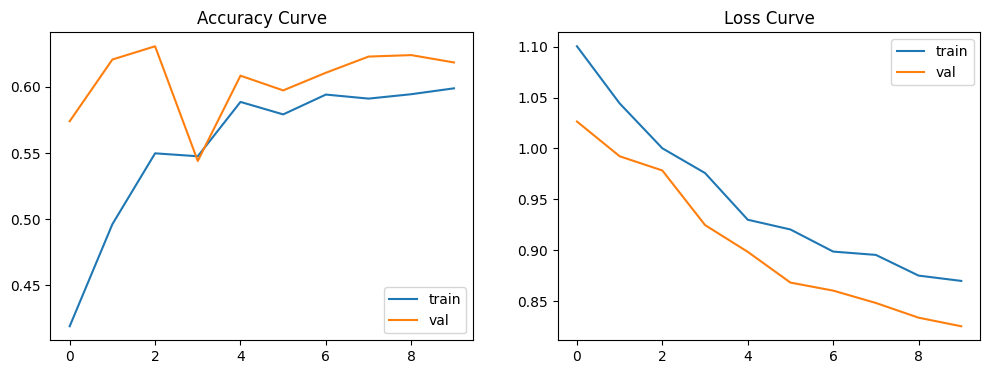

In [12]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss Curve")
plt.legend()

plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 175ms/step
              precision    recall  f1-score   support

  aggressive       0.00      0.00      0.00         0
        deep       0.43      0.70      0.53       381
     healthy       0.36      0.30      0.33       335
     surface       0.00      0.00      0.00       183

    accuracy                           0.41       899
   macro avg       0.20      0.25      0.21       899
weighted avg       0.32      0.41      0.35       899



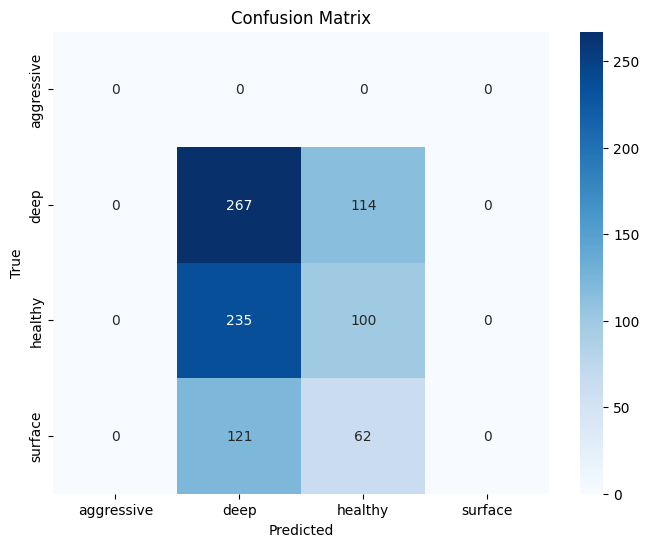

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Collect true labels
y_true = np.concatenate([y.numpy() for x, y in val_ds], axis=0)

# Predict
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Force all 4 labels
labels = list(range(len(class_names)))

print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Dataset
DATASET = "/content/research_dataset"
IMG_SIZE = (224,224)
BATCH = 32
EPOCHS = 10

train_ds = image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

val_ds = image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

class_names = train_ds.class_names
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# CBAM FIXED
def cbam_block(x, ratio=8):
    ch = int(x.shape[-1])

    # Channel Attention
    avg = layers.GlobalAveragePooling2D()(x)
    maxp = layers.GlobalMaxPooling2D()(x)

    shared_dense1 = layers.Dense(ch // ratio, activation="relu")
    shared_dense2 = layers.Dense(ch)

    avg = shared_dense2(shared_dense1(avg))
    maxp = shared_dense2(shared_dense1(maxp))

    ca = layers.Add()([avg, maxp])
    ca = layers.Activation("sigmoid")(ca)
    ca = layers.Reshape((1,1,ch))(ca)

    x = layers.Multiply()([x, ca])

    # Spatial Attention
    avg_pool = layers.Lambda(lambda z: tf.reduce_mean(z, axis=-1, keepdims=True))(x)
    max_pool = layers.Lambda(lambda z: tf.reduce_max(z, axis=-1, keepdims=True))(x)

    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])

    sa = layers.Conv2D(1, kernel_size=7, padding="same", activation="sigmoid")(concat)

    x = layers.Multiply()([x, sa])

    return x

# Backbone
base = MobileNetV3Small(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)
base.trainable = False

# Model
inputs = layers.Input(shape=(224,224,3))
x = layers.Rescaling(1./255)(inputs)
x = base(x, training=False)
x = cbam_block(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

heca_model = Model(inputs, outputs)

heca_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = heca_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

heca_model.save("/content/heca_mobilenet.keras")
print("HECA model saved.")

Found 4499 files belonging to 4 classes.
Using 3600 files for training.
Found 4499 files belonging to 4 classes.
Using 899 files for validation.
Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 30s 162ms/step - accuracy: 0.4269 - loss: 1.0998 - val_accuracy: 0.6407 - val_loss: 1.0325
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.5308 - loss: 1.0106 - val_accuracy: 0.6385 - val_loss: 0.9390
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.5814 - loss: 0.9346 - val_accuracy: 0.6229 - val_loss: 0.8789
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.5972 - loss: 0.8906 - val_accuracy: 0.6463 - val_loss: 0.8549
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.6044 - loss: 0.8544 - val_accuracy: 0.6352 - val_loss: 0.8156
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.6078 - loss: 0.8468 - val_accuracy: 0.6318 - val_loss: 0.7884
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.6228 - loss:

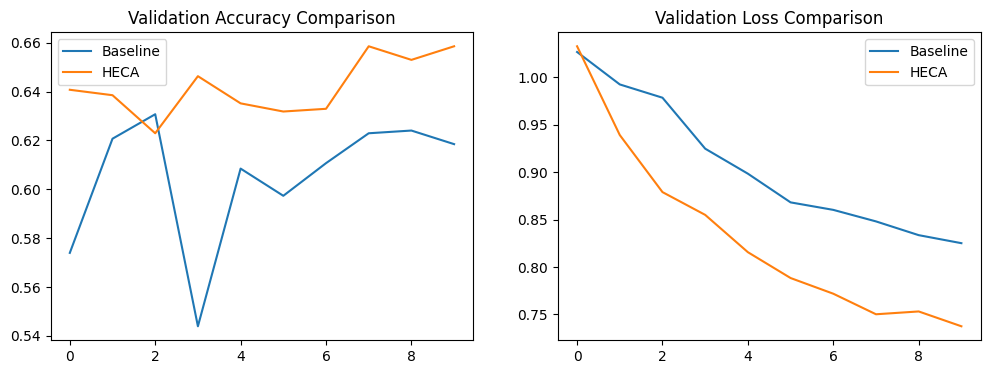

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["val_accuracy"], label="Baseline")
plt.plot(history2.history["val_accuracy"], label="HECA")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["val_loss"], label="Baseline")
plt.plot(history2.history["val_loss"], label="HECA")
plt.title("Validation Loss Comparison")
plt.legend()

plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step
              precision    recall  f1-score   support

  aggressive       0.00      0.00      0.00         0
        deep       0.42      0.75      0.54       381
     healthy       0.36      0.24      0.29       335
     surface       0.00      0.00      0.00       183

    accuracy                           0.41       899
   macro avg       0.20      0.25      0.21       899
weighted avg       0.31      0.41      0.34       899



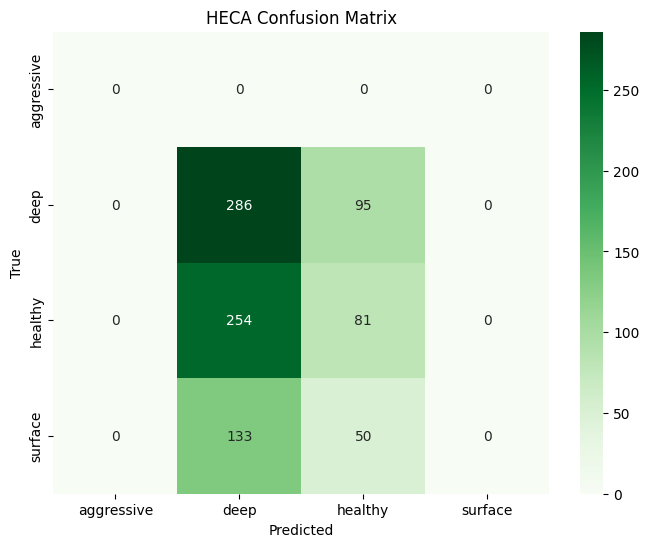

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

y_true = np.concatenate([y.numpy() for x, y in val_ds], axis=0)

y_pred_probs = heca_model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

labels = list(range(len(class_names)))

print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("HECA Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Additional Attention Model Experiments

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV3Small

# SE Block
def se_block(x, ratio=8):
    ch = int(x.shape[-1])

    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(ch // ratio, activation="relu")(se)
    se = layers.Dense(ch, activation="sigmoid")(se)
    se = layers.Reshape((1,1,ch))(se)

    return layers.Multiply()([x, se])

# Backbone
base_se = MobileNetV3Small(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)
base_se.trainable = False

inputs = layers.Input(shape=(224,224,3))
x = layers.Rescaling(1./255)(inputs)
x = base_se(x, training=False)
x = se_block(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

se_model = Model(inputs, outputs)

se_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history3 = se_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

print("SE Model done.")

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 29s 170ms/step - accuracy: 0.4306 - loss: 1.1046 - val_accuracy: 0.6018 - val_loss: 1.0175
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.5386 - loss: 1.0096 - val_accuracy: 0.5751 - val_loss: 0.9423
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.5739 - loss: 0.9446 - val_accuracy: 0.5907 - val_loss: 0.8915
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5944 - loss: 0.9072 - val_accuracy: 0.6162 - val_loss: 0.8600
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.5936 - loss: 0.8763 - val_accuracy: 0.6129 - val_loss: 0.8355
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.5986 - loss: 0.8635 - val_accuracy: 0.6251 - val_loss: 0.8225
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.5975 - loss: 0.8508 - val_accuracy: 0.6296 - val_loss: 0.8109
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.6058 - loss: 0.8338 - val_

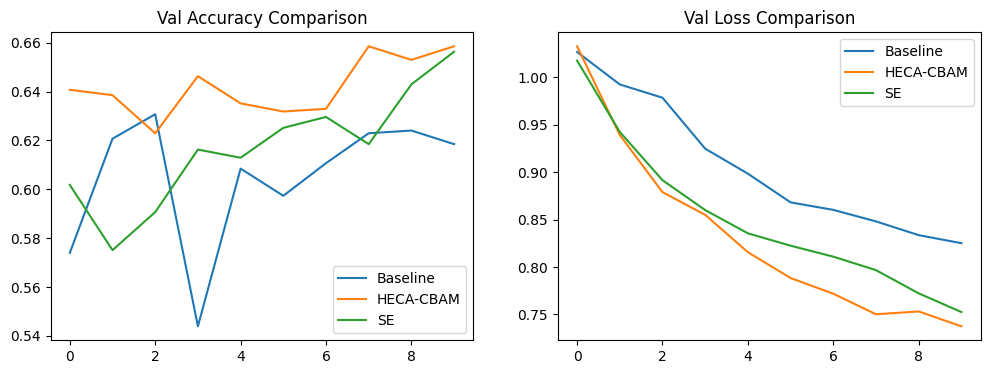

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["val_accuracy"], label="Baseline")
plt.plot(history2.history["val_accuracy"], label="HECA-CBAM")
plt.plot(history3.history["val_accuracy"], label="SE")
plt.title("Val Accuracy Comparison")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["val_loss"], label="Baseline")
plt.plot(history2.history["val_loss"], label="HECA-CBAM")
plt.plot(history3.history["val_loss"], label="SE")
plt.title("Val Loss Comparison")
plt.legend()

plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step


/tmp/ipykernel_1675/3925015179.py:13: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)


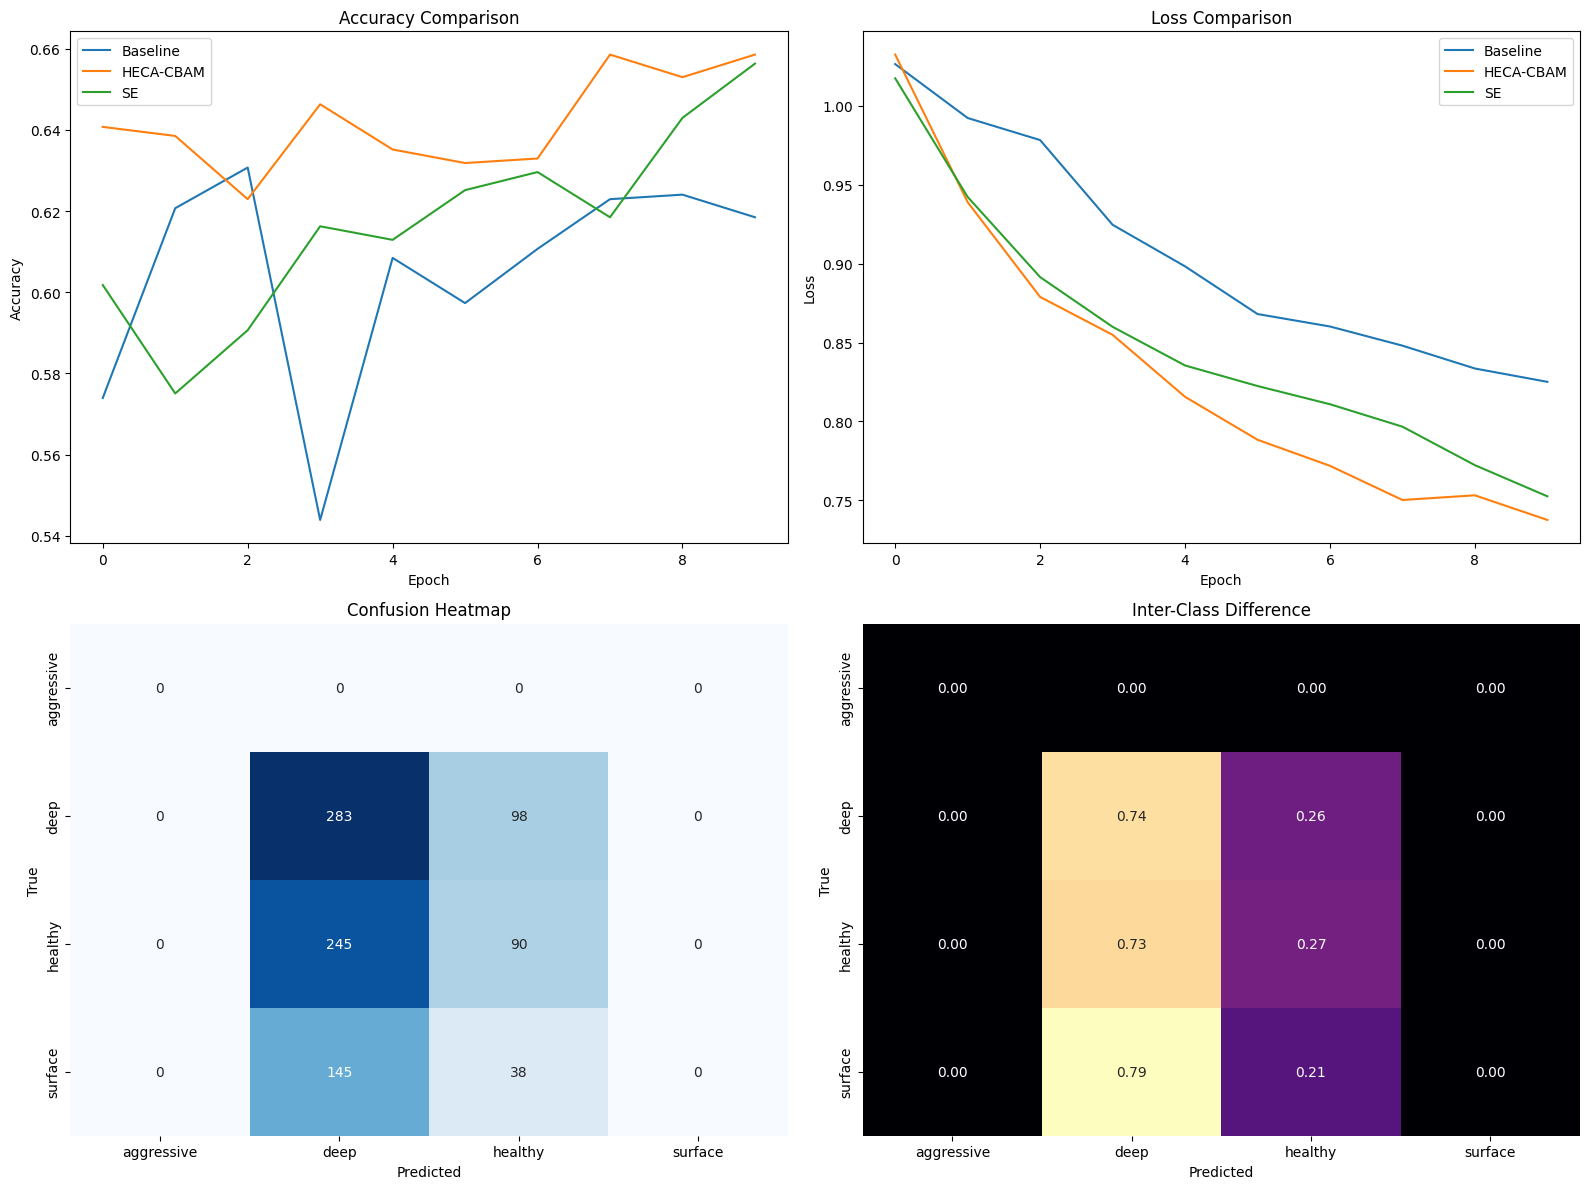

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predictions
y_true = np.concatenate([y.numpy() for x, y in val_ds], axis=0)
y_pred = np.argmax(heca_model.predict(val_ds), axis=1)

cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3])

# Normalized matrix
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

# Figure
plt.figure(figsize=(16,12))

# 1 Accuracy
plt.subplot(2,2,1)
plt.plot(history.history["val_accuracy"], label="Baseline")
plt.plot(history2.history["val_accuracy"], label="HECA-CBAM")
plt.plot(history3.history["val_accuracy"], label="SE")
plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# 2 Loss
plt.subplot(2,2,2)
plt.plot(history.history["val_loss"], label="Baseline")
plt.plot(history2.history["val_loss"], label="HECA-CBAM")
plt.plot(history3.history["val_loss"], label="SE")
plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# 3 Heatmap
plt.subplot(2,2,3)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False
)
plt.title("Confusion Heatmap")
plt.xlabel("Predicted")
plt.ylabel("True")

# 4 Inter-Class Difference
plt.subplot(2,2,4)
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="magma",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False
)
plt.title("Inter-Class Difference")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()